# Compétition 1 : Prédiction de la Qualité de la Bière 🍺

Ce notebook fournit du code de démarrage pour la compétition de prédiction de la qualité de la bière. Pour les instructions complètes, l'énoncé du problème et les critères de notation, veuillez vous référer au fichier **README.md**.

**Résumé rapide** : Vous allez construire un modèle de classification pour prédire la qualité de la bière (scores 1-10) basé sur des propriétés chimiques. Soumettez vos prédictions sur [Kaggle](https://www.kaggle.com/competitions/ift-6390-ift-3395-beer-quality-prediction/).

## Importer les Dépendances

In [ ]:
# Importer les bibliothèques requises
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier, KernelDensity
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

## Charger et Explorer les Données

In [67]:
# Charger les données d'entraînement
train_df = pd.read_csv('data/train.csv', delimiter=';')

print(f"Forme des données d'entraînement : {train_df.shape}")
print(f"Nombre d'échantillons (n) : {train_df.shape[0]}")
print(f"Nombre de caractéristiques (d) : {train_df.shape[1] - 1}")  # Soustraire 1 pour la colonne cible
print(f"Colonnes : {list(train_df.columns)}")
print("\nPremières lignes :")
print(train_df.head())

# Vérifier les types de données et informations de base
print("\nTypes de données et informations :")
print(train_df.info())

####################################################################
###############   À compléter   ####################################
####################################################################

Forme des données d'entraînement : (4469, 15)
Nombre d'échantillons (n) : 4469
Nombre de caractéristiques (d) : 14
Colonnes : ['id', 'beer_style', 'bitterness_IBU', 'diacetyl_concentration', 'lactic_acid', 'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen', 'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV', 'fermentation_strength', 'quality']

Premières lignes :
   id beer_style  bitterness_IBU  diacetyl_concentration  lactic_acid  \
0   0       Pale           7.997                   0.446        0.280   
1   1       Pale           6.906                   0.222        0.303   
2   2      Brown           7.183                   0.636        0.071   
3   3       Pale           6.403                   0.242        0.260   
4   4      Brown           7.917                   0.182        0.347   

   final_gravity  sodium  free_CO2  dissolved_oxygen  original_gravity     pH  \
0         10.803   0.052    24.999           157.026             0.995  3.057   
1          6.305   0.

## Prétraitement des Données

Implémentez votre pipeline de prétraitement (voir README.md pour des suggestions).

In [ ]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Fonction pour détecter et clipper les valeurs aberrantes
def clip_outliers(df, num_cols):
    # Clipping des valeurs aberrantes selon l'IQR
    for col in num_cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# Fonction du pipeline de pretraitement

def data_processor(df):
  df = df.copy()
  # 1. Séparation des données num et cat
  num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid',
                  'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen',
                  'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                    'fermentation_strength']
  cat_cols = ['beer_style']
  # Encodage onehot des données catégorielles

  ohe = OneHotEncoder(sparse_output=False)
  beer_style_encoded = ohe.fit_transform(df[['beer_style']])
  cat_columns_names = ohe.get_feature_names_out(['beer_style'])

  cat_df = pd.DataFrame(
      beer_style_encoded,
      columns=cat_columns_names,
      index=df.index
  )
  # Transformation des données numériques (plusieurs tests
  # ont été fait pour trouver la meilleure)
  df[num_cols] = np.sqrt(df[num_cols])

  # Imputation des données na
  imputer = SimpleImputer(strategy='mean')
  df[num_cols] = imputer.fit_transform(df[num_cols])

  # Standardisation pour les données numériques
  scaler = StandardScaler()
  features_scaled = scaler.fit_transform(df[num_cols])
  features_df = pd.DataFrame(features_scaled, columns=num_cols, index=df.index)

  # Sélection des caractéristiques et concaténation num et cat
  processed_df = features_df.copy()
  features_df = features_df[['diacetyl_concentration', 'alcohol_ABV', 'gypsum_level']]
  features_df = pd.concat([features_df, cat_df], axis=1)

  return features_df, num_cols, processed_df

# Prétraitement des données

train_df = pd.read_csv('data/train.csv', delimiter=';')

# Vérifier le nombre de valeurs manquantes par colonne
print("NULL VALUES IN train_df",train_df.isna().sum().sum())
print(train_df.isna().sum().sort_values(ascending=False))

# On clip les valeurs aberrantes avant le process des datas
num_cols = ['bitterness_IBU', 'diacetyl_concentration', 'lactic_acid',
                  'final_gravity', 'sodium', 'free_CO2', 'dissolved_oxygen',
                  'original_gravity', 'pH', 'gypsum_level', 'alcohol_ABV',
                    'fermentation_strength']
train_df = clip_outliers(train_df, num_cols)
features_df, num_cols, processed_df = data_processor(train_df)

processed_df = pd.concat([processed_df, train_df[['quality', 'beer_style']]], axis=1)


# Matrice de corrélation
plt.figure(figsize=(12, 10))
correlation_matrix = train_df[num_cols + ['quality']].corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matrice de Corrélation')
plt.show()

quality_correlations = correlation_matrix['quality'].drop('quality').sort_values(ascending=False)
print("Corrélations avec la qualité :")
print(quality_correlations)

# QUELQUES VISUALISATIONS
# Visualisation de la relation entre fermentation_strength et alcohol_ABV
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='fermentation_strength', y='alcohol_ABV',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Fermentation Strength vs Alcohol ABV')
plt.xlabel('Fermentation Strength')
plt.ylabel('Alcohol ABV')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Linéaire donc redondant?

# Visualisation de la distribution de la qualité par style de bière
plt.figure(figsize=(12, 6))
sns.boxplot(data=processed_df, x='beer_style', y='quality')
plt.title('Distribution de la Qualité par Style de Bière')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# On remarque que la distribution de la qualité est la même pour
# chaque style, on peut donc ne pas prendre en compte cette
# caractéristique

# Graph alcohol ve diacetyle_concentration
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='diacetyl_concentration',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs diacetyl concentration')
plt.xlabel('alcohol ABV')
plt.ylabel('diacetyl concentration')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph dissolbed_oxygen and lactic acid
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='lactic_acid',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Lactic Acid')
plt.xlabel('alcohol ABV')
plt.ylabel('Lactic Acid')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph diacetyl_concentration and sodium
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='sodium',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Sodium')
plt.xlabel('alcohol ABV')
plt.ylabel('Sodium')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph original gravity and final gravity
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='final_gravity',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('alcohol ABV vs Final Gravity')
plt.xlabel('alcohol ABV')
plt.ylabel('Final Gravity')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph alcohol ABV ve Bitterness IBU
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='bitterness_IBU',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs bitterness IBU')
plt.xlabel('Alcohol ABV')
plt.ylabel('bitterness_IBU')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()
# Aucune conclusion

# Graph alcohol ABV vs free CO2
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='free_CO2',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Free CO2')
plt.xlabel('Alcohol ABV')
plt.ylabel('Free CO2')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs dissolved oxygen
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='dissolved_oxygen',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs dissolved oxygen')
plt.xlabel('Alcohol ABV')
plt.ylabel('dissolved oxygen')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs original gravity
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='original_gravity',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Original Gravity')
plt.xlabel('Alcohol ABV')
plt.ylabel('Original Gravity')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Graph alcohol ABV vs gysum level
plt.figure(figsize=(10, 8))
sns.scatterplot(data=processed_df, x='alcohol_ABV', y='gypsum_level',
                hue='quality', palette='viridis', size='quality', sizes=(50, 200))
plt.title('Alcohol ABV vs Gypsum Level')
plt.xlabel('Alcohol ABV')
plt.ylabel('Gypsum Level')
plt.legend(title='Quality', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Distribution de la qualité par style de bière
plt.figure(figsize=(12, 6))
sns.boxplot(data=processed_df, x='beer_style', y='quality')
plt.title('Distribution de la Qualité par Style de Bière')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
# On remarque que la distribution de la qualité est la même pour
# chaque style, on peut donc ne pas prendre en compte cette
# caractéristique

display(features_df)

# Observation du nombre d'échantillons par classe de qualité
print(train_df['quality'].value_counts())
# On remarque un déséquilibre des classes, on pourrait envisager
# des techniques de rééchantillonnage plus tard.

from sklearn.ensemble import RandomForestClassifier

# Utilise toutes les features prétraitées
X = features_df
y = train_df['quality']

# Entrainement du modèle
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
rf_model.fit(X, y)

# Importance des features
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Importance des caractéristiques selon Random Forest :")
print(importances.head(15))

# Après impression de la matrice de corrélation et de l'importance des caractéristiques, et la
# visualtisation des données,
# on décide de ne garder que les trois caractéristiques numériques les plus importantes :
# 'diacetyl_concentration', 'alcohol_ABV', 'gypsum_level,' ainsi que les caractéristiques
# catégorielles encodées.









## Préparer les Données d'Entraînement et de Validation

Divisez vos données en ensembles d'entraînement et de validation.

In [74]:
from sklearn.model_selection import train_test_split

X = features_df
y = train_df['quality']

# On stratifie la séparation pour maintenir la distribution des classes
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, 
    test_size=0.33, 
    random_state=42,
    stratify=y  
)



## Entraîner les Modèles

Entraînez et comparez plusieurs modèles d'apprentissage automatique.

Best k for K-nn: 25
K-nn Accuracy: 0.5336
Classification Report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         7
           4       0.00      0.00      0.00        38
           5       0.59      0.55      0.57       494
           6       0.51      0.69      0.59       655
           7       0.44      0.22      0.30       249
           8       1.00      0.03      0.06        31
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1475
   macro avg       0.36      0.21      0.22      1475
weighted avg       0.52      0.53      0.50      1475



/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

Best radius for Parzen: 0.1
Parzen Accuracy: 0.4746
Classification Report:
               precision    recall  f1-score   support

           3       0.01      0.14      0.02         7
           4       0.04      0.13      0.06        38
           5       0.50      0.61      0.55       494
           6       0.51      0.51      0.51       655
           7       0.00      0.00      0.00       249
           8       0.00      0.00      0.00        31
           9       0.00      0.00      0.00         1

    accuracy                           0.43      1475
   macro avg       0.15      0.20      0.16      1475
weighted avg       0.40      0.43      0.41      1475



/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave


Best Kernel & C:
Kernel          poly
C                0.1
Accuracy    0.451525
Name: 11, dtype: object


/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/alixloungnarath/miniconda3/envs/.venv/li

Best Logistic Regression Configuration :
Solver          saga
C                0.1
Accuracy    0.378983
Name: 11, dtype: object
Random Forest Best Parameters: (100, 20)
Random Forrest Best Accuracy: 0.5206779661016949


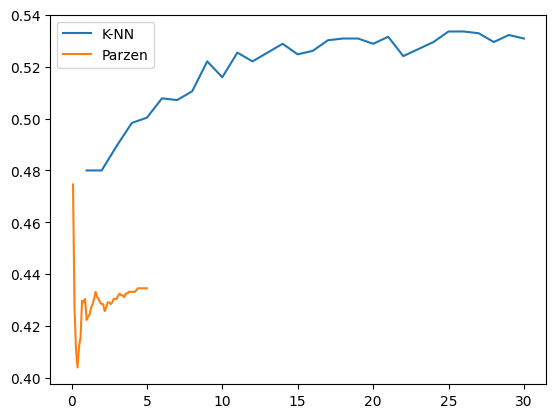

✅ Best Params: n_estimators=200, learning_rate=0.01, max_depth=5
✅ Best Accuracy: 0.5525


In [ ]:
####################################################################
###############   À compléter   ####################################
####################################################################
#######################################################################

# On donne des poids aux classes pour la regression logistique
class_counts = {
    3: 21,
    4: 116,
    5: 1496,
    6: 1985,
    7: 755,
    8: 93,
    9: 3
}

# Calcul du poids inversement proportionnel à la fréquence
total = sum(class_counts.values())
class_weight = {cls: total / (len(class_counts) * count) for cls, count in class_counts.items()}

# 1. K-nn
k = np.arange(1, 31)
# Trouver la meilleure valeur de k entre 1 et 31
accuracies_knn = []
best_accuracy = 0
for k_value in k:
    neigh = KNeighborsClassifier(n_neighbors=k_value, weights='distance')
    neigh.fit(X_train, y_train)
    y_pred_knn = neigh.predict(X_valid)
    accuracy_knn = accuracy_score(y_valid, y_pred_knn)
    accuracies_knn.append(accuracy_knn)
    # Sauvegarder le meilleur modèle
    if accuracy_knn > best_accuracy:
        best_accuracy = accuracy_knn
        best_k = k_value
        best_predictions = y_pred_knn
        best_model = neigh

# On trouve l'indice du meilleur k
k_index = np.argmax(accuracies_knn)
best_k = k[k_index]


print(f"Best k for K-nn: {best_k}")
print(f"K-nn Accuracy: {accuracies_knn[k_index]:.4f}")
print("Classification Report:\n", classification_report(y_valid, y_pred_knn))
# cm = confusion_matrix(y_valid, y_pred_knn)
#plt.figure(figsize=(8, 6))
# sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
#plt.title('K-nn Confusion Matrix')
#plt.xlabel('Predicted')
#plt.ylabel('Actual')
#plt.show()

# 2. Parzen
radius = np.arange(0.1, 5.1, 0.1)
# trouver la meilleure valeur de radius entre 0.1 et 10.0
accuracies_parzen = []
for radius_value in radius:
    # liste pour stocker les kde de chaque classe
    kdes = []

    # un kde par classe
    for class_idx in range(7):  # Classes 0-6
        mask = (y_train == class_idx)
        if np.sum(mask) > 0:
            kde = KernelDensity(bandwidth=radius_value, kernel='gaussian')
            kde.fit(X_train[mask])
            kdes.append(kde)
        else:
            kdes.append(None)

    # calcul des densités
    log_probs = np.zeros((len(X_valid), 7))
    for class_idx in range(7):
        if kdes[class_idx] is not None:
            log_probs[:, class_idx] = kdes[class_idx].score_samples(X_valid)
        else:
            log_probs[:, class_idx] = -np.inf

    # choisir la classe avec la plus haute densité
    y_pred_parzen = np.argmax(log_probs, axis=1)
    accuracy_parzen = accuracy_score(y_valid, y_pred_parzen)
    accuracies_parzen.append(accuracy_parzen)

# on trouve l'indice du meilleur radius
radius_index = np.argmax(accuracies_parzen)
best_radius = radius[radius_index]
print(f"Best radius for Parzen: {best_radius}")
print(f"Parzen Accuracy: {accuracies_parzen[radius_index]:.4f}")
print("Classification Report:\n", classification_report(y_valid, y_pred_parzen))


# 3. SVM
kernels = ['linear', 'rbf', 'poly', 'sigmoid']
c_values = [0.01, 0.1, 1, 10, 100]
results_svm = []

for kernel in kernels:
    for c in c_values:
        if kernel == 'poly':
            svm_model = SVC(kernel=kernel, C=c, degree=3, gamma='scale', class_weight=class_weight)
        else:
            svm_model = SVC(kernel=kernel, C=c, gamma='scale', class_weight=class_weight)

        svm_model.fit(X_train, y_train)
        y_pred = svm_model.predict(X_valid)
        acc = accuracy_score(y_valid, y_pred)

        results_svm.append((kernel, c, acc))

# Résultats enDataFrame
results_svm_df = pd.DataFrame(results_svm, columns=['Kernel', 'C', 'Accuracy'])
# On trouve la meilleure combinaison
best_row = results_svm_df.loc[results_svm_df['Accuracy'].idxmax()]
print("\nBest Kernel & C:")
print(best_row)



# 4 Regression Logistique

c_values = [0.01, 0.1, 1, 10, 100]
solvers = ['lbfgs', 'newton-cg', 'saga']

results_logreg = []

for solver in solvers:
    for c in c_values:
        logreg = LogisticRegression(
            penalty='l2',
            C=c,
            solver=solver,
            max_iter=2000,
            multi_class='multinomial',
            class_weight=class_weight
        )
        logreg.fit(X_train, y_train)
        y_pred = logreg.predict(X_valid)
        acc = accuracy_score(y_valid, y_pred)
        results_logreg.append((solver, c, acc))

# Conversion en DataFrame pour bien lire
results_logreg_df = pd.DataFrame(results_logreg, columns=['Solver', 'C', 'Accuracy'])

# Meilleurs résultats
best_logreg = results_logreg_df.loc[results_logreg_df['Accuracy'].idxmax()]
print("Best Logistic Regression Configuration :")
print(best_logreg)

# 5. Random Forest Classifier

# Grille des parametres que l'on veut tester
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, 30]
}

best_score = 0
best_params = None

for n in param_grid['n_estimators']:
    for depth in param_grid['max_depth']:
        rf = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            min_samples_split=10,
            min_samples_leaf=3,
            class_weight=class_weight,
            random_state=42
        )
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_valid)
        accuracy = accuracy_score(y_valid, y_pred)

        if accuracy > best_score:
            best_score = accuracy
            best_params = (n, depth)

print("Random Forest Best Parameters:", best_params)
print("Random Forrest Best Accuracy:", best_score)




plt.plot(k, accuracies_knn, label='K-NN')
plt.plot(radius, accuracies_parzen, label='Parzen')
plt.legend()
plt.show()

# 6. Gradient Boosting Classifier


n_estimators_list = [100, 200, 300]
learning_rates = [0.01, 0.05, 0.1, 0.2]
max_depths = [1, 3, 5]
best_gb_acc = 0
best_gb_params = None

for n in n_estimators_list:
    for lr in learning_rates:
        for depth in max_depths:
            clf = GradientBoostingClassifier(
                n_estimators=n,
                learning_rate=lr,
                max_depth=depth,
                random_state=42
            )
            clf.fit(X_train, y_train)
            y_pred = clf.predict(X_valid)
            acc = accuracy_score(y_valid, y_pred)
            if acc > best_gb_acc:
                best_gb_acc = acc
                best_gb_params = (n, lr, depth)

print(f"Best Params: n_estimators={best_gb_params[0]}, learning_rate={best_gb_params[1]}, max_depth={best_gb_params[2]}")
print(f"Best Accuracy: {best_gb_acc:.4f}")



## Évaluer les Modèles

Analysez la performance de votre meilleur modèle (voir README.md pour les directives d'évaluation).

In [102]:
####################################################################
###############   À compléter   ####################################
####################################################################

# Maintenant on prévoit les y de test
# Charger les données de test
test_df = pd.read_csv('data/test.csv', delimiter=';')

# On prépare les données de la même facon que X_train
X_test, _, _= data_processor(test_df)

# On réentraine le modèle sur toutes les données d'entraînement (X, y)
final_model = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.01,
    max_depth=5,
    random_state=42
)
final_model.fit(X, y)

# Évaluer la performance sur les données d'entraînement
y_train_pred = final_model.predict(X)
train_accuracy = accuracy_score(y, y_train_pred)
print("Final Model Training Accuracy: {:.4f}".format(train_accuracy))

# Prédiction X_test
prediction = final_model.predict(X_test)


/home/alixloungnarath/miniconda3/envs/.venv/lib/python3.13/site-packages/pandas/core/internals/blocks.py:395: RuntimeWarning: invalid value encountered in sqrt
  result = func(self.values, **kwargs)


Final Model Training Accuracy: 0.6576


## Générer les Prédictions pour la Soumission Kaggle

Créez un fichier CSV avec les colonnes : `id` et `quality` (voir README.md pour les détails du format).

In [104]:

####################################################################
###############   À compléter   ####################################
####################################################################

output_df = pd.DataFrame({
    'id': range(len(prediction)),  # les id sont les index
    'quality': prediction
})

# Sauvegarder en CSV
output_df.to_csv('predictions.csv', index=False)

---
Bonne chance pour la compétition ! 🍺
